# Notebook 08: Calibration and Selective Prediction — Main19

This notebook compares confidence reliability and selective prediction across:

1. EfficientNet-B0 baseline
2. EfficientNetV2-S proposed CNN
3. ViT-B/16 transformer

## Strict protocol

- No model is retrained in this notebook.
- No temperature parameter is refit in this notebook.
- No threshold is selected using the internal test set.
- Abstention thresholds are selected only from calibration predictions.
- The locked internal-test predictions are used once to report final risk–coverage behaviour.

Definitions:

- Coverage: fraction of examples accepted by the model.
- Selective risk: error rate among accepted examples.
- Abstention: the model declines to produce a disease prediction below a selected confidence threshold.

In [1]:
import os
import json
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

SEED = 7

np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.0.2
Pandas: 2.3.3


In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,

    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 1.2,

    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "legend.fontsize": 11,
    "legend.frameon": True,
    "legend.edgecolor": "0.4",

    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.85,
})


def paper_axes(ax):
    ax.minorticks_on()

    ax.grid(
        True,
        which="major",
        linestyle=":",
        linewidth=0.8
    )

    ax.grid(
        True,
        which="minor",
        linestyle=":",
        linewidth=0.5,
        alpha=0.7
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )


print("Professional paper plotting style enabled.")

Professional paper plotting style enabled.


In [3]:
INPUT_ROOT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")

OUTPUT_DIR = WORK_DIR / "calibration_and_selective_prediction_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
METADATA_DIR = OUTPUT_DIR / "metadata"

for folder in [
    OUTPUT_DIR,
    FIG_DIR,
    TABLE_DIR,
    METADATA_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Input root:", INPUT_ROOT)
print("Output directory:", OUTPUT_DIR)

Input root: /kaggle/input
Output directory: /kaggle/working/calibration_and_selective_prediction_outputs


In [4]:
csv_files = sorted(INPUT_ROOT.rglob("*.csv"))

prediction_candidates = []

for csv_path in csv_files:
    try:
        columns = pd.read_csv(csv_path, nrows=2).columns.tolist()

        if (
            "confidence" in columns
            and (
                "correct" in columns
                or "predicted_label" in columns
                or "predicted_label_uncal" in columns
            )
        ):
            prediction_candidates.append({
                "file_name": csv_path.name,
                "path": str(csv_path),
                "columns": ", ".join(columns[:12])
            })

    except Exception:
        pass

candidate_df = pd.DataFrame(prediction_candidates)

display(candidate_df)

print("Prediction-file candidates found:", len(candidate_df))

,file_name,path,columns
0,calibration_predictions_best_model.csv,/kaggle/input/datasets/katakuricharlotte/crop-...,"image_path, label, true_class_index, predicted..."
1,proposed_calibration_predictions.csv,/kaggle/input/datasets/katakuricharlotte/crop-...,"image_path, label, true_class_index, predicted..."
2,vit_calibration_predictions.csv,/kaggle/input/datasets/katakuricharlotte/crop-...,"image_path, label, true_class_index, predicted..."
3,vit_test_predictions.csv,/kaggle/input/datasets/katakuricharlotte/crop-...,"image_path, label, true_class_index, predicted..."


Prediction-file candidates found: 4


In [5]:
# -------------------------------------------------------------
# Replace only if automatic discovery below selects a wrong file.
# -------------------------------------------------------------

def find_file_by_name(file_name):
    matches = list(INPUT_ROOT.rglob(file_name))

    if len(matches) == 0:
        return None

    if len(matches) > 1:
        print(f"Multiple matches for {file_name}:")
        for match in matches:
            print(" -", match)

    return matches[0]


# Baseline calibration predictions from Notebook 03.
BASELINE_CALIBRATION_PATH = find_file_by_name(
    "calibration_predictions_best_model.csv"
)

# Baseline test predictions from Notebook 04.
# The code below searches likely filenames. Set manually if needed.
BASELINE_TEST_PATH = find_file_by_name(
    "test_predictions_uncalibrated_and_calibrated.csv"
)

# Proposed CNN calibration predictions from Notebook 05.
PROPOSED_CALIBRATION_PATH = find_file_by_name(
    "proposed_calibration_predictions.csv"
)

# Proposed CNN test predictions from Notebook 06.
PROPOSED_TEST_PATH = find_file_by_name(
    "proposed_test_predictions.csv"
)

# ViT calibration predictions from the Notebook-07 add-on cell.
VIT_CALIBRATION_PATH = find_file_by_name(
    "vit_calibration_predictions.csv"
)

# ViT test predictions from Notebook 07.
VIT_TEST_PATH = find_file_by_name(
    "vit_test_predictions.csv"
)

paths_to_check = {
    "Baseline calibration": BASELINE_CALIBRATION_PATH,
    "Baseline test": BASELINE_TEST_PATH,
    "Proposed CNN calibration": PROPOSED_CALIBRATION_PATH,
    "Proposed CNN test": PROPOSED_TEST_PATH,
    "ViT calibration": VIT_CALIBRATION_PATH,
    "ViT test": VIT_TEST_PATH
}

for name, path in paths_to_check.items():
    print(f"{name}: {path}")

assert BASELINE_CALIBRATION_PATH is not None, (
    "Baseline calibration prediction CSV not found."
)

assert PROPOSED_CALIBRATION_PATH is not None, (
    "Proposed CNN calibration prediction CSV not found."
)

assert PROPOSED_TEST_PATH is not None, (
    "Proposed CNN test prediction CSV not found."
)

assert VIT_CALIBRATION_PATH is not None, (
    "ViT calibration prediction CSV not found. "
    "Run the Notebook-07 add-on export cell first."
)

assert VIT_TEST_PATH is not None, (
    "ViT test prediction CSV not found."
)

assert BASELINE_TEST_PATH is not None, (
    "Baseline test prediction CSV was not found automatically. "
    "Use Cell 5 to identify the correct Notebook-04 prediction file, "
    "then assign its exact path manually in this cell."
)

Baseline calibration: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/calibration_predictions_best_model.csv
Baseline test: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb_4567_8/nb_4567_8/test_predictions_uncalibrated_and_calibrated.csv
Proposed CNN calibration: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb_4567_8/nb_4567_8/proposed_calibration_predictions.csv
Proposed CNN test: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb_4567_8/nb_4567_8/proposed_test_predictions.csv
ViT calibration: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb_4567_8/nb_4567_8/vit_calibration_predictions.csv
ViT test: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb_4567_8/nb_4567_8/vit_test_predictions.csv


In [6]:
baseline_calibration_raw = pd.read_csv(
    BASELINE_CALIBRATION_PATH
)

baseline_test_raw = pd.read_csv(
    BASELINE_TEST_PATH
)

proposed_calibration_raw = pd.read_csv(
    PROPOSED_CALIBRATION_PATH
)

proposed_test_raw = pd.read_csv(
    PROPOSED_TEST_PATH
)

vit_calibration_raw = pd.read_csv(
    VIT_CALIBRATION_PATH
)

vit_test_raw = pd.read_csv(
    VIT_TEST_PATH
)

prediction_inputs = {
    "baseline_calibration": baseline_calibration_raw,
    "baseline_test": baseline_test_raw,
    "proposed_calibration": proposed_calibration_raw,
    "proposed_test": proposed_test_raw,
    "vit_calibration": vit_calibration_raw,
    "vit_test": vit_test_raw
}

for name, dataframe in prediction_inputs.items():
    print(f"\n{name}")
    print("Shape:", dataframe.shape)
    print("Columns:", dataframe.columns.tolist())


baseline_calibration
Shape: (3197, 25)
Columns: ['image_path', 'label', 'true_class_index', 'predicted_class_index', 'predicted_label', 'confidence', 'probability_00_bell_pepper__bacterial_spot', 'probability_01_bell_pepper__healthy', 'probability_02_corn__cercospora_leaf_spot_gray_leaf_spot', 'probability_03_corn__common_rust', 'probability_04_corn__healthy', 'probability_05_corn__northern_leaf_blight', 'probability_06_potato__early_blight', 'probability_07_potato__healthy', 'probability_08_potato__late_blight', 'probability_09_tomato__bacterial_spot', 'probability_10_tomato__early_blight', 'probability_11_tomato__healthy', 'probability_12_tomato__late_blight', 'probability_13_tomato__leaf_mold', 'probability_14_tomato__septoria_leaf_spot', 'probability_15_tomato__spider_mites_two_spotted_spider_mite', 'probability_16_tomato__target_spot', 'probability_17_tomato__tomato_mosaic_virus', 'probability_18_tomato__tomato_yellow_leaf_curl_virus']

baseline_test
Shape: (5322, 47)
Columns: ['

In [7]:
def first_existing_column(dataframe, candidates):
    for column_name in candidates:
        if column_name in dataframe.columns:
            return column_name

    return None


def standardize_prediction_dataframe(
    dataframe,
    model_name,
    split_name
):
    dataframe = dataframe.copy()

    true_label_column = first_existing_column(
        dataframe,
        ["label", "true_label"]
    )

    true_index_column = first_existing_column(
        dataframe,
        ["true_class_index", "target", "true_index"]
    )

    prediction_label_column = first_existing_column(
        dataframe,
        [
            "predicted_label",
            "predicted_label_uncal",
            "prediction_label",
            "predicted_class"
        ]
    )

    prediction_index_column = first_existing_column(
        dataframe,
        [
            "predicted_class_index",
            "predicted_class_index_uncal",
            "prediction_index",
            "predicted_index"
        ]
    )

    confidence_column = first_existing_column(
        dataframe,
        [
            "confidence",
            "confidence_uncal",
            "max_probability"
        ]
    )

    correct_column = first_existing_column(
        dataframe,
        [
            "correct",
            "correct_uncal",
            "is_correct"
        ]
    )

    assert true_label_column is not None, (
        f"{model_name} {split_name}: true label column not found."
    )

    assert confidence_column is not None, (
        f"{model_name} {split_name}: confidence column not found."
    )

    standardized = pd.DataFrame({
        "model": model_name,
        "split": split_name,
        "image_path": dataframe.get(
            "image_path",
            pd.Series(
                [None] * len(dataframe),
                index=dataframe.index
            )
        ),
        "true_label": dataframe[true_label_column].astype(str),
        "confidence": dataframe[confidence_column].astype(float)
    })

    if prediction_label_column is not None:
        standardized["predicted_label"] = dataframe[
            prediction_label_column
        ].astype(str)

    elif prediction_index_column is not None:
        standardized["predicted_label"] = dataframe[
            prediction_index_column
        ].astype(str)

    else:
        raise ValueError(
            f"{model_name} {split_name}: prediction column not found."
        )

    if true_index_column is not None:
        standardized["true_class_index"] = dataframe[
            true_index_column
        ]

    if prediction_index_column is not None:
        standardized["predicted_class_index"] = dataframe[
            prediction_index_column
        ]

    if correct_column is not None:
        standardized["correct"] = (
            dataframe[correct_column]
            .astype(bool)
        )
    else:
        standardized["correct"] = (
            standardized["true_label"]
            == standardized["predicted_label"]
        )

    assert standardized["confidence"].between(0, 1).all(), (
        f"{model_name} {split_name}: confidence values are outside [0, 1]."
    )

    return standardized


baseline_calibration_df = standardize_prediction_dataframe(
    baseline_calibration_raw,
    model_name="EfficientNet-B0",
    split_name="calibration"
)

baseline_test_df = standardize_prediction_dataframe(
    baseline_test_raw,
    model_name="EfficientNet-B0",
    split_name="internal_test"
)

proposed_calibration_df = standardize_prediction_dataframe(
    proposed_calibration_raw,
    model_name="EfficientNetV2-S",
    split_name="calibration"
)

proposed_test_df = standardize_prediction_dataframe(
    proposed_test_raw,
    model_name="EfficientNetV2-S",
    split_name="internal_test"
)

vit_calibration_df = standardize_prediction_dataframe(
    vit_calibration_raw,
    model_name="ViT-B/16",
    split_name="calibration"
)

vit_test_df = standardize_prediction_dataframe(
    vit_test_raw,
    model_name="ViT-B/16",
    split_name="internal_test"
)

calibration_predictions = pd.concat(
    [
        baseline_calibration_df,
        proposed_calibration_df,
        vit_calibration_df
    ],
    ignore_index=True
)

test_predictions = pd.concat(
    [
        baseline_test_df,
        proposed_test_df,
        vit_test_df
    ],
    ignore_index=True
)

print("Calibration rows:", len(calibration_predictions))
print("Test rows:", len(test_predictions))

display(
    calibration_predictions.groupby(
        ["model", "split"]
    ).agg(
        images=("correct", "size"),
        accuracy=("correct", "mean"),
        mean_confidence=("confidence", "mean")
    ).reset_index()
)

Calibration rows: 9591
Test rows: 15966


,model,split,images,accuracy,mean_confidence
0,EfficientNet-B0,calibration,3197,0.995934,0.998689
1,EfficientNetV2-S,calibration,3197,0.998123,0.993738
2,ViT-B/16,calibration,3197,0.995934,0.884999


In [8]:
expected_models = {
    "EfficientNet-B0",
    "EfficientNetV2-S",
    "ViT-B/16"
}

assert set(calibration_predictions["model"]) == expected_models
assert set(test_predictions["model"]) == expected_models

assert (
    calibration_predictions
    .groupby("model")
    .size()
    .eq(3197)
    .all()
), "Each model must have 3,197 calibration predictions."

assert (
    test_predictions
    .groupby("model")
    .size()
    .eq(5322)
    .all()
), "Each model must have 5,322 internal-test predictions."

for model_name in sorted(expected_models):
    calibration_paths = set(
        calibration_predictions.loc[
            calibration_predictions["model"] == model_name,
            "image_path"
        ]
    )

    test_paths = set(
        test_predictions.loc[
            test_predictions["model"] == model_name,
            "image_path"
        ]
    )

    assert calibration_paths.isdisjoint(test_paths), (
        f"{model_name}: calibration and test predictions overlap."
    )

print("PASS: All models have complete, disjoint calibration/test predictions.")

PASS: All models have complete, disjoint calibration/test predictions.


In [9]:
def top_label_ece(
    confidence,
    correctness,
    n_bins=15
):
    confidence = np.asarray(confidence)
    correctness = np.asarray(correctness).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for index in range(n_bins):
        lower = bin_edges[index]
        upper = bin_edges[index + 1]

        in_bin = (
            (confidence > lower)
            & (confidence <= upper)
        )

        if in_bin.sum() == 0:
            continue

        bin_accuracy = correctness[in_bin].mean()
        bin_confidence = confidence[in_bin].mean()

        ece += (
            in_bin.mean()
            * abs(bin_accuracy - bin_confidence)
        )

    return float(ece)


def confidence_bins(
    dataframe,
    n_bins=15
):
    records = []

    edges = np.linspace(0.0, 1.0, n_bins + 1)

    for index in range(n_bins):
        lower = edges[index]
        upper = edges[index + 1]

        in_bin = dataframe[
            (dataframe["confidence"] > lower)
            & (dataframe["confidence"] <= upper)
        ]

        if len(in_bin) == 0:
            continue

        records.append({
            "bin_lower": lower,
            "bin_upper": upper,
            "bin_center": (lower + upper) / 2,
            "count": len(in_bin),
            "fraction": len(in_bin) / len(dataframe),
            "mean_confidence": in_bin["confidence"].mean(),
            "accuracy": in_bin["correct"].mean()
        })

    return pd.DataFrame(records)


def summary_metrics(dataframe):
    return {
        "images": int(len(dataframe)),
        "accuracy": float(dataframe["correct"].mean()),
        "mean_confidence": float(dataframe["confidence"].mean()),
        "top_label_ece": top_label_ece(
            dataframe["confidence"],
            dataframe["correct"],
            n_bins=15
        )
    }


calibration_summary_rows = []

for model_name, model_df in calibration_predictions.groupby("model"):
    row = {
        "model": model_name,
        "split": "calibration",
        **summary_metrics(model_df)
    }

    calibration_summary_rows.append(row)

calibration_summary_df = pd.DataFrame(
    calibration_summary_rows
).sort_values("model")

display(calibration_summary_df)

,model,split,images,accuracy,mean_confidence,top_label_ece
0,EfficientNet-B0,calibration,3197,0.995934,0.998689,0.003701
1,EfficientNetV2-S,calibration,3197,0.998123,0.993738,0.004386
2,ViT-B/16,calibration,3197,0.995934,0.884999,0.111700


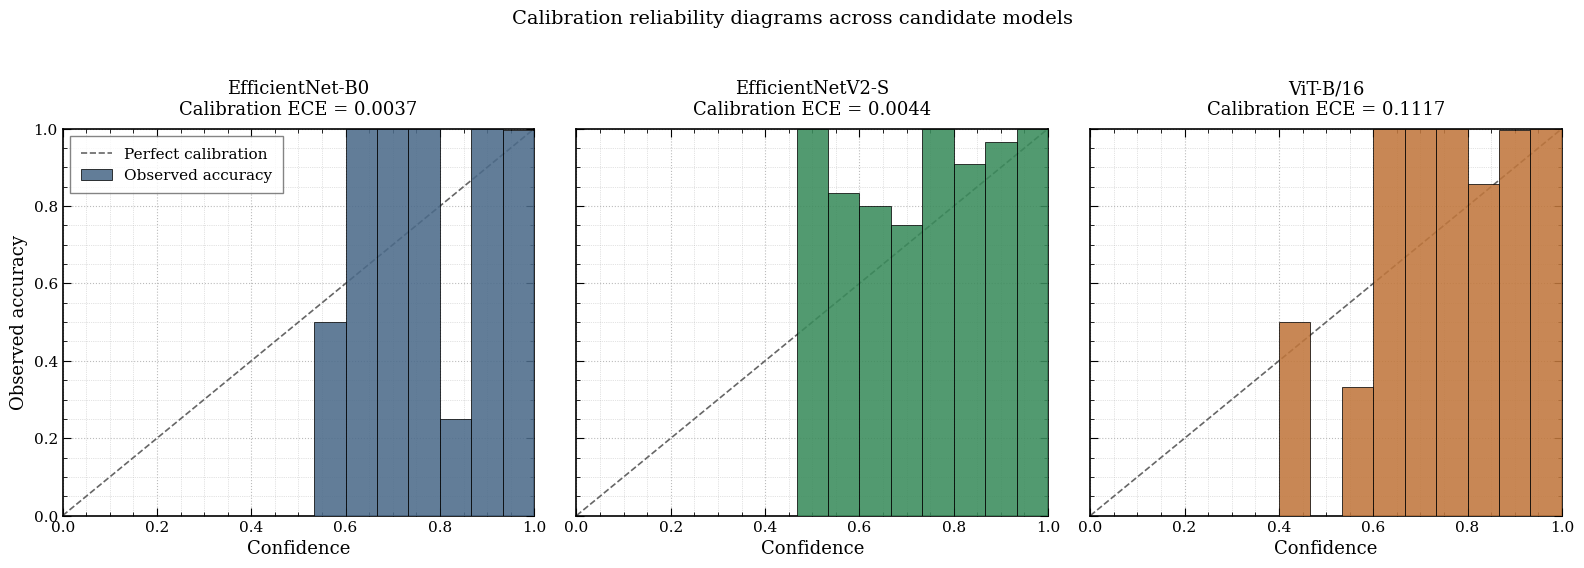

Saved: /kaggle/working/calibration_and_selective_prediction_outputs/figures/fig_01_calibration_reliability_all_models.png


In [10]:
models_order = [
    "EfficientNet-B0",
    "EfficientNetV2-S",
    "ViT-B/16"
]

colors = {
    "EfficientNet-B0": "#4C6B8A",
    "EfficientNetV2-S": "#3A8C5C",
    "ViT-B/16": "#C1773D"
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5.5),
    sharex=True,
    sharey=True
)

for axis, model_name in zip(axes, models_order):
    model_df = calibration_predictions[
        calibration_predictions["model"] == model_name
    ]

    bins_df = confidence_bins(
        model_df,
        n_bins=15
    )

    ece_value = top_label_ece(
        model_df["confidence"],
        model_df["correct"],
        n_bins=15
    )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="0.4",
        linewidth=1.2,
        label="Perfect calibration"
    )

    axis.bar(
        bins_df["bin_center"],
        bins_df["accuracy"],
        width=1 / 15,
        color=colors[model_name],
        edgecolor="black",
        linewidth=0.6,
        alpha=0.88,
        label="Observed accuracy",
        zorder=3
    )

    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)

    axis.set_xlabel("Confidence")
    axis.set_title(
        f"{model_name}\nCalibration ECE = {ece_value:.4f}",
        pad=10
    )

    paper_axes(axis)

axes[0].set_ylabel("Observed accuracy")

axes[0].legend(
    loc="upper left",
    fancybox=False,
    borderpad=0.7
)

fig.suptitle(
    "Calibration reliability diagrams across candidate models",
    y=1.03,
    fontsize=14
)

plt.tight_layout()

reliability_png = FIG_DIR / "fig_01_calibration_reliability_all_models.png"
reliability_pdf = FIG_DIR / "fig_01_calibration_reliability_all_models.pdf"

plt.savefig(
    reliability_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    reliability_pdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:", reliability_png)

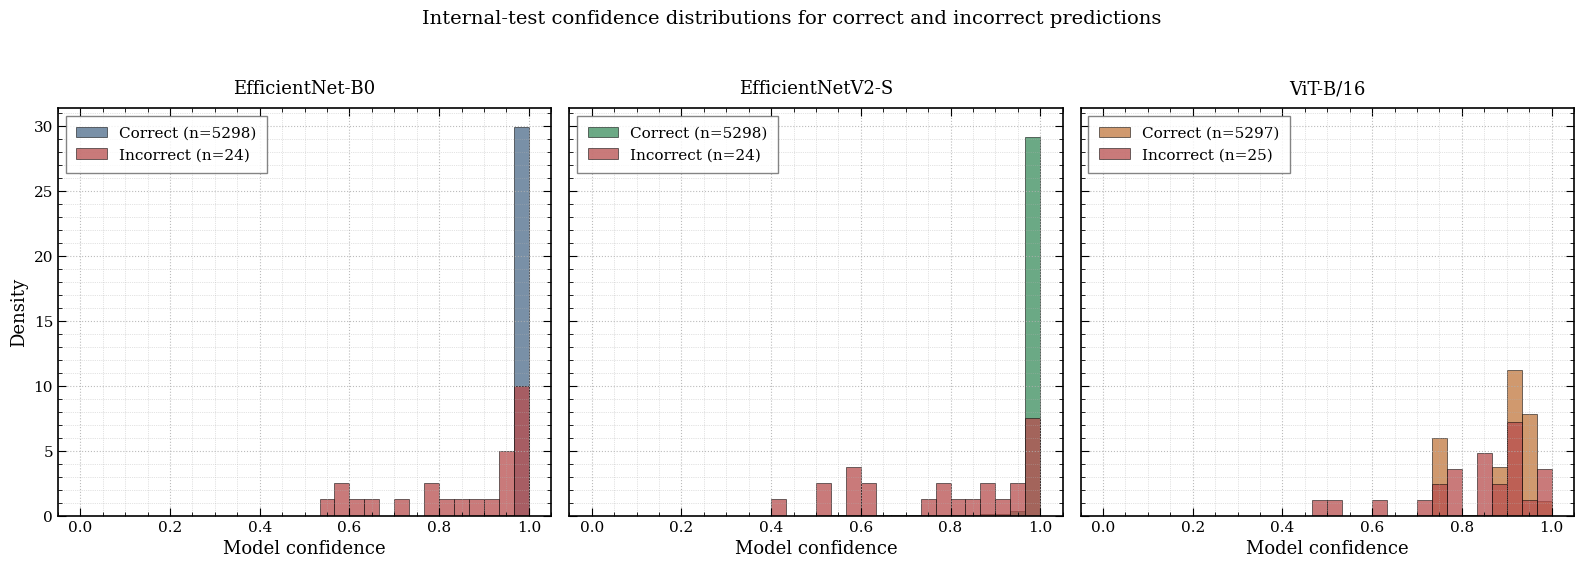

Saved: /kaggle/working/calibration_and_selective_prediction_outputs/figures/fig_02_test_confidence_correct_vs_incorrect.png


In [11]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5.5),
    sharex=True,
    sharey=True
)

bins = np.linspace(0.0, 1.0, 31)

for axis, model_name in zip(axes, models_order):
    model_df = test_predictions[
        test_predictions["model"] == model_name
    ]

    correct_confidence = model_df.loc[
        model_df["correct"],
        "confidence"
    ]

    incorrect_confidence = model_df.loc[
        ~model_df["correct"],
        "confidence"
    ]

    axis.hist(
        correct_confidence,
        bins=bins,
        density=True,
        color=colors[model_name],
        alpha=0.75,
        edgecolor="black",
        linewidth=0.5,
        label=(
            "Correct "
            f"(n={len(correct_confidence)})"
        )
    )

    if len(incorrect_confidence) > 0:
        axis.hist(
            incorrect_confidence,
            bins=bins,
            density=True,
            color="#B74D4D",
            alpha=0.75,
            edgecolor="black",
            linewidth=0.5,
            label=(
                "Incorrect "
                f"(n={len(incorrect_confidence)})"
            )
        )

    axis.set_xlabel("Model confidence")
    axis.set_title(model_name, pad=10)

    paper_axes(axis)

    axis.legend(
        loc="upper left",
        fancybox=False,
        borderpad=0.7
    )

axes[0].set_ylabel("Density")

fig.suptitle(
    "Internal-test confidence distributions for correct and incorrect predictions",
    y=1.03,
    fontsize=14
)

plt.tight_layout()

confidence_png = (
    FIG_DIR / "fig_02_test_confidence_correct_vs_incorrect.png"
)

confidence_pdf = (
    FIG_DIR / "fig_02_test_confidence_correct_vs_incorrect.pdf"
)

plt.savefig(
    confidence_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    confidence_pdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:", confidence_png)

In [12]:
def risk_coverage_curve(
    dataframe,
    thresholds=None
):
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 201)

    records = []

    for threshold in thresholds:
        accepted = dataframe[
            dataframe["confidence"] >= threshold
        ]

        coverage = len(accepted) / len(dataframe)

        if len(accepted) == 0:
            risk = np.nan
            selective_accuracy = np.nan
        else:
            selective_accuracy = accepted["correct"].mean()
            risk = 1.0 - selective_accuracy

        records.append({
            "threshold": float(threshold),
            "accepted_images": int(len(accepted)),
            "coverage": float(coverage),
            "selective_accuracy": selective_accuracy,
            "selective_risk": risk
        })

    return pd.DataFrame(records)


calibration_curves = {}
test_curves = {}

for model_name in models_order:
    calibration_model_df = calibration_predictions[
        calibration_predictions["model"] == model_name
    ]

    test_model_df = test_predictions[
        test_predictions["model"] == model_name
    ]

    calibration_curves[model_name] = risk_coverage_curve(
        calibration_model_df
    )

    test_curves[model_name] = risk_coverage_curve(
        test_model_df
    )

print("Risk–coverage curves created.")

Risk–coverage curves created.


In [13]:
TARGET_RISK = 0.01
MIN_THRESHOLD = 0.50

threshold_rows = []

for model_name in models_order:
    curve_df = calibration_curves[model_name].copy()

    eligible = curve_df[
        (curve_df["threshold"] >= MIN_THRESHOLD)
        & (curve_df["coverage"] > 0)
        & (curve_df["selective_risk"] <= TARGET_RISK)
    ].copy()

    if len(eligible) > 0:
        selected = eligible.sort_values(
            ["coverage", "threshold"],
            ascending=[False, True]
        ).iloc[0]

        selection_status = (
            f"Highest coverage with calibration risk <= {TARGET_RISK:.0%}, "
            f"threshold >= {MIN_THRESHOLD:.2f}"
        )
    else:
        selected = curve_df[
            (curve_df["threshold"] >= MIN_THRESHOLD)
            & (curve_df["coverage"] > 0)
        ].sort_values(
            ["selective_risk", "threshold"],
            ascending=[True, True]
        ).iloc[0]

        selection_status = (
            f"No threshold achieved calibration risk <= {TARGET_RISK:.0%}; "
            "minimum-risk threshold used with threshold constraint"
        )

    threshold_rows.append({
        "model": model_name,
        "target_risk": TARGET_RISK,
        "minimum_allowed_threshold": MIN_THRESHOLD,
        "selected_threshold": selected["threshold"],
        "calibration_coverage": selected["coverage"],
        "calibration_risk": selected["selective_risk"],
        "calibration_selective_accuracy": (
            selected["selective_accuracy"]
        ),
        "selection_status": selection_status
    })

thresholds_df = pd.DataFrame(threshold_rows)

thresholds_path = (
    TABLE_DIR /
    "selective_prediction_thresholds_calibration_only_v2.csv"
)

thresholds_df.to_csv(
    thresholds_path,
    index=False
)

display(thresholds_df)
print("Saved:", thresholds_path)

,model,target_risk,minimum_allowed_threshold,selected_threshold,calibration_coverage,calibration_risk,calibration_selective_accuracy,selection_status
0,EfficientNet-B0,0.010000,0.500000,0.500000,1.000000,0.004066,0.995934,"Highest coverage with calibration risk <= 1%, ..."
1,EfficientNetV2-S,0.010000,0.500000,0.500000,0.999687,0.001877,0.998123,"Highest coverage with calibration risk <= 1%, ..."
2,ViT-B/16,0.010000,0.500000,0.500000,0.999062,0.003444,0.996556,"Highest coverage with calibration risk <= 1%, ..."


Saved: /kaggle/working/calibration_and_selective_prediction_outputs/tables/selective_prediction_thresholds_calibration_only_v2.csv


In [14]:
def operating_point_at_coverage(
    dataframe,
    target_coverage
):
    target_coverage = float(target_coverage)

    threshold = dataframe["confidence"].quantile(
        1.0 - target_coverage,
        interpolation="lower"
    )

    accepted = dataframe[
        dataframe["confidence"] >= threshold
    ].copy()

    if len(accepted) == 0:
        return {
            "threshold": threshold,
            "accepted_images": 0,
            "coverage": 0.0,
            "selective_accuracy": np.nan,
            "selective_risk": np.nan
        }

    return {
        "threshold": float(threshold),
        "accepted_images": int(len(accepted)),
        "coverage": float(len(accepted) / len(dataframe)),
        "selective_accuracy": float(accepted["correct"].mean()),
        "selective_risk": float(1.0 - accepted["correct"].mean())
    }


coverage_targets = [0.95, 0.98, 0.99, 1.00]

fixed_coverage_rows = []

for model_name in models_order:
    calibration_model_df = calibration_predictions[
        calibration_predictions["model"] == model_name
    ]

    test_model_df = test_predictions[
        test_predictions["model"] == model_name
    ]

    for target_coverage in coverage_targets:
        calibration_point = operating_point_at_coverage(
            calibration_model_df,
            target_coverage
        )

        threshold = calibration_point["threshold"]

        accepted_test = test_model_df[
            test_model_df["confidence"] >= threshold
        ].copy()

        if len(accepted_test) > 0:
            test_coverage = len(accepted_test) / len(test_model_df)
            test_accuracy = accepted_test["correct"].mean()
            test_risk = 1.0 - test_accuracy
        else:
            test_coverage = 0.0
            test_accuracy = np.nan
            test_risk = np.nan

        fixed_coverage_rows.append({
            "model": model_name,
            "target_calibration_coverage": target_coverage,
            "threshold_selected_on_calibration": threshold,
            "calibration_coverage": calibration_point["coverage"],
            "calibration_risk": calibration_point["selective_risk"],
            "test_coverage": test_coverage,
            "test_selective_accuracy": test_accuracy,
            "test_selective_risk": test_risk
        })

fixed_coverage_df = pd.DataFrame(fixed_coverage_rows)

fixed_coverage_path = (
    TABLE_DIR / "fixed_coverage_selective_prediction_results.csv"
)

fixed_coverage_df.to_csv(
    fixed_coverage_path,
    index=False
)

display(fixed_coverage_df)

print("Saved:", fixed_coverage_path)

,model,target_calibration_coverage,threshold_selected_on_calibration,calibration_coverage,calibration_risk,test_coverage,test_selective_accuracy,test_selective_risk
0,EfficientNet-B0,0.950000,0.999500,0.968408,0.001292,0.961856,0.999219,0.000781
1,EfficientNet-B0,0.980000,0.998000,0.981232,0.001594,0.978579,0.999232,0.000768
2,EfficientNet-B0,0.990000,0.991700,0.990303,0.001895,0.989290,0.999050,0.000950
3,EfficientNet-B0,1.000000,0.510300,1.000000,0.004066,0.999812,0.995490,0.004510
4,EfficientNetV2-S,0.950000,0.981000,0.951204,0.000000,0.952086,0.999211,0.000789
5,EfficientNetV2-S,0.980000,0.931000,0.980294,0.000319,0.981022,0.998276,0.001724
6,EfficientNetV2-S,0.990000,0.843300,0.990303,0.000948,0.990981,0.997725,0.002275
7,EfficientNetV2-S,1.000000,0.470200,1.000000,0.001877,0.999812,0.995678,0.004322
8,ViT-B/16,0.950000,0.742000,0.954332,0.002950,0.920519,0.995918,0.004082
9,ViT-B/16,0.980000,0.739300,0.980294,0.002872,0.971064,0.996130,0.003870


Saved: /kaggle/working/calibration_and_selective_prediction_outputs/tables/fixed_coverage_selective_prediction_results.csv


In [15]:
test_selective_rows = []

for _, threshold_record in thresholds_df.iterrows():
    model_name = threshold_record["model"]
    threshold = threshold_record["selected_threshold"]

    model_df = test_predictions[
        test_predictions["model"] == model_name
    ].copy()

    accepted = model_df[
        model_df["confidence"] >= threshold
    ].copy()

    rejected = model_df[
        model_df["confidence"] < threshold
    ].copy()

    coverage = len(accepted) / len(model_df)
    abstention_rate = len(rejected) / len(model_df)

    if len(accepted) > 0:
        selective_accuracy = accepted["correct"].mean()
        selective_risk = 1.0 - selective_accuracy
    else:
        selective_accuracy = np.nan
        selective_risk = np.nan

    test_selective_rows.append({
        "model": model_name,
        "threshold_selected_on_calibration": threshold,
        "test_images": len(model_df),
        "accepted_images": len(accepted),
        "rejected_images": len(rejected),
        "test_coverage": coverage,
        "test_abstention_rate": abstention_rate,
        "test_selective_accuracy": selective_accuracy,
        "test_selective_risk": selective_risk,
        "full_test_accuracy": model_df["correct"].mean()
    })

test_selective_df = pd.DataFrame(
    test_selective_rows
)

test_selective_path = (
    TABLE_DIR / "selective_prediction_test_results.csv"
)

test_selective_df.to_csv(
    test_selective_path,
    index=False
)

display(test_selective_df)

print("Saved:", test_selective_path)

,model,threshold_selected_on_calibration,test_images,accepted_images,rejected_images,test_coverage,test_abstention_rate,test_selective_accuracy,test_selective_risk,full_test_accuracy
0,EfficientNet-B0,0.500000,5322,5322,0,1.000000,0.000000,0.995490,0.004510,0.995490
1,EfficientNetV2-S,0.500000,5322,5320,2,0.999624,0.000376,0.995677,0.004323,0.995490
2,ViT-B/16,0.500000,5322,5319,3,0.999436,0.000564,0.995488,0.004512,0.995303


Saved: /kaggle/working/calibration_and_selective_prediction_outputs/tables/selective_prediction_test_results.csv


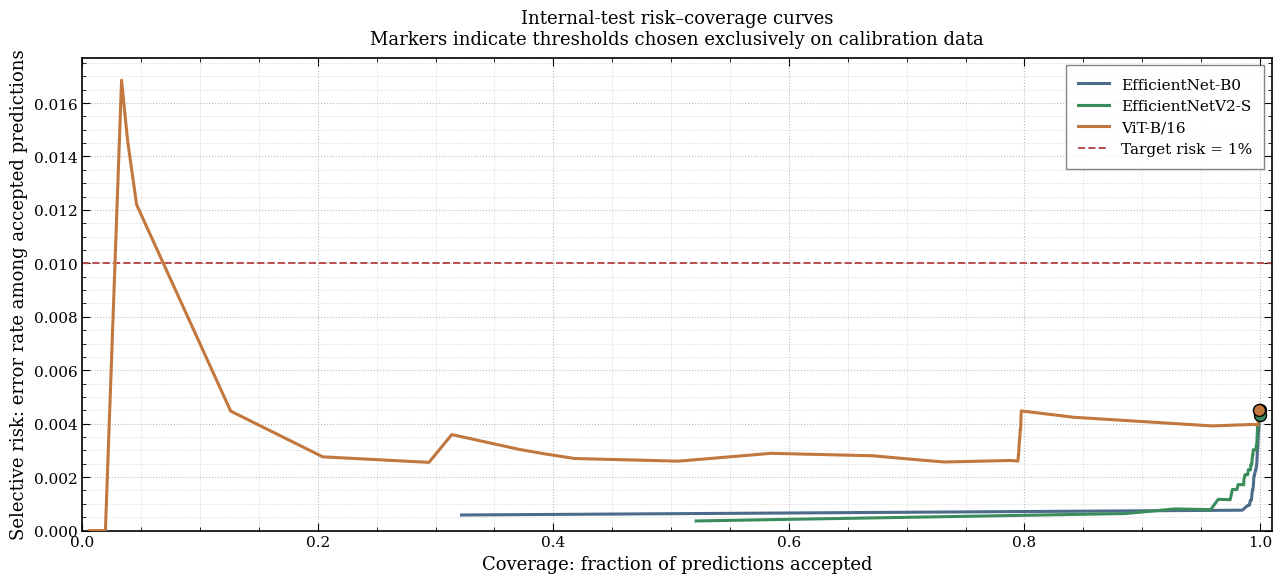

Saved: /kaggle/working/calibration_and_selective_prediction_outputs/figures/fig_03_internal_test_risk_coverage_curves.png


In [16]:
fig, ax = plt.subplots(figsize=(13, 6))

for model_name in models_order:
    curve_df = test_curves[model_name]

    valid_curve = curve_df.dropna(
        subset=["selective_risk"]
    )

    ax.plot(
        valid_curve["coverage"],
        valid_curve["selective_risk"],
        linewidth=2.2,
        color=colors[model_name],
        label=model_name,
        zorder=3
    )

    model_threshold = thresholds_df.loc[
        thresholds_df["model"] == model_name,
        "selected_threshold"
    ].iloc[0]

    selected_row = valid_curve.iloc[
        (
            valid_curve["threshold"]
            - model_threshold
        ).abs().argmin()
    ]

    ax.scatter(
        selected_row["coverage"],
        selected_row["selective_risk"],
        color=colors[model_name],
        edgecolor="black",
        s=75,
        zorder=5
    )

ax.axhline(
    TARGET_RISK,
    color="#B74D4D",
    linestyle="--",
    linewidth=1.4,
    label=f"Target risk = {TARGET_RISK:.0%}"
)

ax.set_xlim(0, 1.01)
ax.set_ylim(bottom=0)

ax.set_xlabel("Coverage: fraction of predictions accepted")
ax.set_ylabel("Selective risk: error rate among accepted predictions")

ax.set_title(
    "Internal-test risk–coverage curves\n"
    "Markers indicate thresholds chosen exclusively on calibration data",
    pad=10
)

paper_axes(ax)

ax.legend(
    loc="upper right",
    fancybox=False,
    borderpad=0.8
)

plt.tight_layout()

risk_coverage_png = (
    FIG_DIR / "fig_03_internal_test_risk_coverage_curves.png"
)

risk_coverage_pdf = (
    FIG_DIR / "fig_03_internal_test_risk_coverage_curves.pdf"
)

plt.savefig(
    risk_coverage_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    risk_coverage_pdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:", risk_coverage_png)

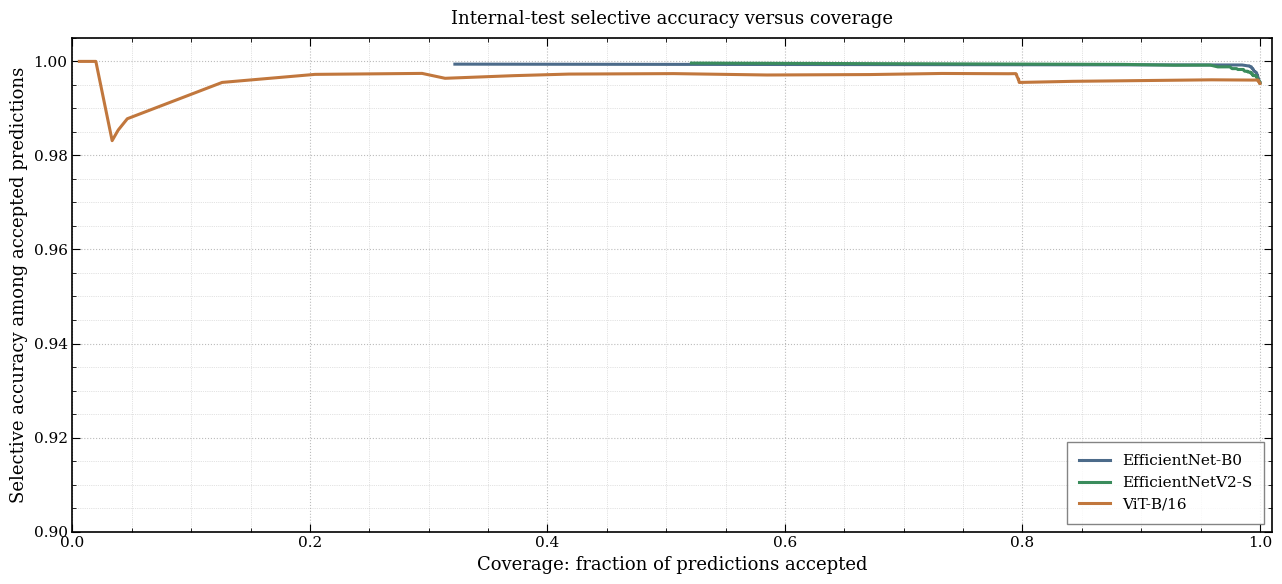

Saved: /kaggle/working/calibration_and_selective_prediction_outputs/figures/fig_04_internal_test_accuracy_coverage_curves.png


In [17]:
fig, ax = plt.subplots(figsize=(13, 6))

for model_name in models_order:
    curve_df = test_curves[model_name]

    valid_curve = curve_df.dropna(
        subset=["selective_accuracy"]
    )

    ax.plot(
        valid_curve["coverage"],
        valid_curve["selective_accuracy"],
        linewidth=2.2,
        color=colors[model_name],
        label=model_name,
        zorder=3
    )

ax.set_xlim(0, 1.01)
ax.set_ylim(0.90, 1.005)

ax.set_xlabel("Coverage: fraction of predictions accepted")
ax.set_ylabel("Selective accuracy among accepted predictions")

ax.set_title(
    "Internal-test selective accuracy versus coverage",
    pad=10
)

paper_axes(ax)

ax.legend(
    loc="lower right",
    fancybox=False,
    borderpad=0.8
)

plt.tight_layout()

accuracy_coverage_png = (
    FIG_DIR / "fig_04_internal_test_accuracy_coverage_curves.png"
)

accuracy_coverage_pdf = (
    FIG_DIR / "fig_04_internal_test_accuracy_coverage_curves.pdf"
)

plt.savefig(
    accuracy_coverage_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    accuracy_coverage_pdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:", accuracy_coverage_png)

In [18]:
threshold_transfer_df = thresholds_df.merge(
    test_selective_df,
    left_on=[
        "model",
        "selected_threshold"
    ],
    right_on=[
        "model",
        "threshold_selected_on_calibration"
    ],
    how="left",
    validate="one_to_one"
)

# Keep one threshold column with a clear calibration-selection name.
threshold_transfer_df = threshold_transfer_df.rename(
    columns={
        "selected_threshold": "threshold_selected_on_calibration"
    }
)

# The right-side duplicate is no longer needed after the merge.
duplicate_threshold_columns = [
    column
    for column in threshold_transfer_df.columns
    if column == "threshold_selected_on_calibration_y"
]

if duplicate_threshold_columns:
    threshold_transfer_df = threshold_transfer_df.drop(
        columns=duplicate_threshold_columns
    )

# Rename the left-side merge output if Pandas added a suffix.
if "threshold_selected_on_calibration_x" in threshold_transfer_df.columns:
    threshold_transfer_df = threshold_transfer_df.rename(
        columns={
            "threshold_selected_on_calibration_x":
            "threshold_selected_on_calibration"
        }
    )

desired_columns = [
    "model",
    "target_risk",
    "threshold_selected_on_calibration",
    "calibration_coverage",
    "calibration_risk",
    "test_coverage",
    "test_selective_risk",
    "test_selective_accuracy",
    "test_abstention_rate",
    "selection_status"
]

existing_columns = [
    column
    for column in desired_columns
    if column in threshold_transfer_df.columns
]

threshold_transfer_df = threshold_transfer_df[
    existing_columns
].copy()

threshold_transfer_path = (
    TABLE_DIR /
    "calibration_to_test_selective_prediction_transfer.csv"
)

threshold_transfer_df.to_csv(
    threshold_transfer_path,
    index=False
)

display(threshold_transfer_df)

print("Saved:", threshold_transfer_path)

,model,target_risk,threshold_selected_on_calibration,threshold_selected_on_calibration,calibration_coverage,calibration_risk,test_coverage,test_selective_risk,test_selective_accuracy,test_abstention_rate,selection_status
0,EfficientNet-B0,0.010000,0.500000,0.500000,1.000000,0.004066,1.000000,0.004510,0.995490,0.000000,"Highest coverage with calibration risk <= 1%, ..."
1,EfficientNetV2-S,0.010000,0.500000,0.500000,0.999687,0.001877,0.999624,0.004323,0.995677,0.000376,"Highest coverage with calibration risk <= 1%, ..."
2,ViT-B/16,0.010000,0.500000,0.500000,0.999062,0.003444,0.999436,0.004512,0.995488,0.000564,"Highest coverage with calibration risk <= 1%, ..."


Saved: /kaggle/working/calibration_and_selective_prediction_outputs/tables/calibration_to_test_selective_prediction_transfer.csv


In [19]:
HIGH_CONFIDENCE_THRESHOLD = 0.90

high_confidence_errors = test_predictions[
    (~test_predictions["correct"])
    & (
        test_predictions["confidence"]
        >= HIGH_CONFIDENCE_THRESHOLD
    )
].copy()

high_confidence_errors = high_confidence_errors.sort_values(
    ["model", "confidence"],
    ascending=[True, False]
)

high_confidence_errors_path = (
    TABLE_DIR / "high_confidence_internal_test_errors.csv"
)

high_confidence_errors.to_csv(
    high_confidence_errors_path,
    index=False
)

print(
    "High-confidence errors:",
    len(high_confidence_errors)
)

display(
    high_confidence_errors[
        [
            "model",
            "true_label",
            "predicted_label",
            "confidence",
            "image_path"
        ]
    ].head(30)
)

print("Saved:", high_confidence_errors_path)

High-confidence errors: 32


,model,true_label,predicted_label,confidence,image_path
466,EfficientNet-B0,corn__northern_leaf_blight,corn__cercospora_leaf_spot_gray_leaf_spot,1.000000,/kaggle/input/datasets/mohitsingh1804/plantvil...
519,EfficientNet-B0,corn__northern_leaf_blight,corn__cercospora_leaf_spot_gray_leaf_spot,1.000000,/kaggle/input/datasets/mohitsingh1804/plantvil...
168,EfficientNet-B0,corn__common_rust,corn__northern_leaf_blight,0.999984,/kaggle/input/datasets/mohitsingh1804/plantvil...
1573,EfficientNet-B0,potato__late_blight,tomato__late_blight,0.999957,/kaggle/input/datasets/mohitsingh1804/plantvil...
357,EfficientNet-B0,corn__northern_leaf_blight,corn__cercospora_leaf_spot_gray_leaf_spot,0.992654,/kaggle/input/datasets/mohitsingh1804/plantvil...
31,EfficientNet-B0,corn__cercospora_leaf_spot_gray_leaf_spot,corn__northern_leaf_blight,0.981092,/kaggle/input/datasets/mohitsingh1804/plantvil...
430,EfficientNet-B0,corn__northern_leaf_blight,corn__cercospora_leaf_spot_gray_leaf_spot,0.969169,/kaggle/input/datasets/mohitsingh1804/plantvil...
63,EfficientNet-B0,corn__cercospora_leaf_spot_gray_leaf_spot,corn__northern_leaf_blight,0.968680,/kaggle/input/datasets/mohitsingh1804/plantvil...
1556,EfficientNet-B0,potato__late_blight,tomato__late_blight,0.955299,/kaggle/input/datasets/mohitsingh1804/plantvil...
349,EfficientNet-B0,corn__northern_leaf_blight,corn__cercospora_leaf_spot_gray_leaf_spot,0.951094,/kaggle/input/datasets/mohitsingh1804/plantvil...


Saved: /kaggle/working/calibration_and_selective_prediction_outputs/tables/high_confidence_internal_test_errors.csv


In [20]:
curve_records = []

for model_name in models_order:
    calibration_curve = calibration_curves[model_name].copy()
    calibration_curve["model"] = model_name
    calibration_curve["split"] = "calibration"

    test_curve = test_curves[model_name].copy()
    test_curve["model"] = model_name
    test_curve["split"] = "internal_test"

    curve_records.extend([
        calibration_curve,
        test_curve
    ])

all_curves_df = pd.concat(
    curve_records,
    ignore_index=True
)

all_curves_path = (
    TABLE_DIR / "risk_coverage_curve_records.csv"
)

all_curves_df.to_csv(
    all_curves_path,
    index=False
)

print("Saved:", all_curves_path)
display(all_curves_df.head())

Saved: /kaggle/working/calibration_and_selective_prediction_outputs/tables/risk_coverage_curve_records.csv


,threshold,accepted_images,coverage,selective_accuracy,selective_risk,model,split
0,0.000000,3197,1.000000,0.995934,0.004066,EfficientNet-B0,calibration
1,0.005000,3197,1.000000,0.995934,0.004066,EfficientNet-B0,calibration
2,0.010000,3197,1.000000,0.995934,0.004066,EfficientNet-B0,calibration
3,0.015000,3197,1.000000,0.995934,0.004066,EfficientNet-B0,calibration
4,0.020000,3197,1.000000,0.995934,0.004066,EfficientNet-B0,calibration


In [21]:
run_metadata = {
    "notebook": "08_calibration_and_selective_prediction",
    "completed_utc": datetime.now(timezone.utc).isoformat(),
    "models": models_order,
    "threshold_selection_split": "calibration only",
    "internal_test_threshold_tuning": False,
    "target_selective_risk": TARGET_RISK,
    "calibration_summary": calibration_summary_df.to_dict(
        orient="records"
    ),
    "selected_thresholds": thresholds_df.to_dict(
        orient="records"
    ),
    "internal_test_selective_results": test_selective_df.to_dict(
        orient="records"
    ),
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__
}

run_metadata_path = (
    METADATA_DIR / "calibration_selective_prediction_metadata.json"
)

with open(run_metadata_path, "w") as file:
    json.dump(run_metadata, file, indent=2)

print(json.dumps(run_metadata, indent=2))

{
  "notebook": "08_calibration_and_selective_prediction",
  "completed_utc": "2026-08-22T16:29:28.213333+00:00",
  "models": [
    "EfficientNet-B0",
    "EfficientNetV2-S",
    "ViT-B/16"
  ],
  "threshold_selection_split": "calibration only",
  "internal_test_threshold_tuning": false,
  "target_selective_risk": 0.01,
  "calibration_summary": [
    {
      "model": "EfficientNet-B0",
      "split": "calibration",
      "images": 3197,
      "accuracy": 0.9959336878323428,
      "mean_confidence": 0.9986894275883641,
      "top_label_ece": 0.003700813262433636
    },
    {
      "model": "EfficientNetV2-S",
      "split": "calibration",
      "images": 3197,
      "accuracy": 0.9981232405380044,
      "mean_confidence": 0.9937376603065373,
      "top_label_ece": 0.004385580231467099
    },
    {
      "model": "ViT-B/16",
      "split": "calibration",
      "images": 3197,
      "accuracy": 0.9959336878323428,
      "mean_confidence": 0.8849992180168909,
      "top_label_ece": 0.11170

In [22]:
assert reliability_png.exists()
assert confidence_png.exists()
assert risk_coverage_png.exists()
assert accuracy_coverage_png.exists()

assert thresholds_path.exists()
assert test_selective_path.exists()
assert threshold_transfer_path.exists()
assert high_confidence_errors_path.exists()
assert all_curves_path.exists()
assert run_metadata_path.exists()

assert set(thresholds_df["model"]) == set(models_order)
assert set(test_selective_df["model"]) == set(models_order)

print("=" * 78)
print("NOTEBOOK 08 COMPLETED")
print("=" * 78)

print("\nThresholds selected only on calibration predictions:")
display(
    thresholds_df[
        [
            "model",
            "selected_threshold",
            "calibration_coverage",
            "calibration_risk"
        ]
    ]
)

print("\nFinal internal-test selective-prediction results:")
display(
    test_selective_df[
        [
            "model",
            "test_coverage",
            "test_selective_accuracy",
            "test_selective_risk",
            "test_abstention_rate"
        ]
    ]
)

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nNext notebook:")
print("09_lesion_grounding_severity_proxy")

NOTEBOOK 08 COMPLETED

Thresholds selected only on calibration predictions:


,model,selected_threshold,calibration_coverage,calibration_risk
0,EfficientNet-B0,0.500000,1.000000,0.004066
1,EfficientNetV2-S,0.500000,0.999687,0.001877
2,ViT-B/16,0.500000,0.999062,0.003444



Final internal-test selective-prediction results:


,model,test_coverage,test_selective_accuracy,test_selective_risk,test_abstention_rate
0,EfficientNet-B0,1.000000,0.995490,0.004510,0.000000
1,EfficientNetV2-S,0.999624,0.995677,0.004323,0.000376
2,ViT-B/16,0.999436,0.995488,0.004512,0.000564



Output directory:
/kaggle/working/calibration_and_selective_prediction_outputs

Next notebook:
09_lesion_grounding_severity_proxy
